In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

In [125]:
df = pd.read_csv("manufacturing_defect_dataset.csv")

print("Dataset shape:", df.shape)
df.info()

Dataset shape: (3240, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64


In [127]:
# Estadísticas descriptivas
display(df.describe())

# Revisar duplicados
duplicates = df.duplicated().sum()
print("Duplicated rows:", duplicates)

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
count,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,548.523148,12423.018476,89.833290,2.558951,2.749116,80.134272,11.476543,2.501373,6.019662,0.050878,90.040115,4.591667,2988.494453,0.299776,5.472098,299.515479,0.840432
std,262.402073,4308.051904,5.759143,1.705804,1.310154,11.611750,6.872684,1.443684,2.329791,0.028797,5.723600,2.896313,1153.420820,0.116400,2.598212,116.379905,0.366261
min,100.000000,5000.174521,80.004820,0.000000,0.500710,60.010098,0.000000,0.001665,2.001611,0.000002,80.004960,0.000000,1000.720156,0.100238,1.000151,100.211137,0.000000
25%,322.000000,8728.829280,84.869219,1.000000,1.598033,70.103420,5.750000,1.264597,3.983249,0.026200,85.180203,2.000000,1988.140273,0.200502,3.228507,194.922058,1.000000
50%,549.000000,12405.204656,89.704861,3.000000,2.708775,80.265312,12.000000,2.465151,6.022389,0.051837,90.125743,5.000000,2996.822301,0.297470,5.437134,299.728918,1.000000
75%,775.250000,16124.462428,94.789936,4.000000,3.904533,90.353822,17.000000,3.774861,8.050222,0.075473,95.050838,7.000000,3984.788299,0.402659,7.741006,403.178283,1.000000
max,999.000000,19993.365549,99.989214,5.000000,4.998529,99.996993,23.000000,4.997591,9.998577,0.099997,99.996786,9.000000,4997.074741,0.499500,9.999749,499.982782,1.000000


Duplicated rows: 0


In [129]:
def detectar_faltantes(df):

    resumen = pd.DataFrame({
        "missing_values": df.isnull().sum(),
        "blank_strings": (df == "").sum()
    })

    resumen["total_problematic"] = resumen["missing_values"] + resumen["blank_strings"]
    resumen["percent"] = (resumen["total_problematic"] / len(df)) * 100

    return resumen.sort_values("total_problematic", ascending=False)

display(detectar_faltantes(df))



,missing_values,blank_strings,total_problematic,percent
ProductionVolume,0,0,0,0.0
StockoutRate,0,0,0,0.0
AdditiveMaterialCost,0,0,0,0.0
AdditiveProcessTime,0,0,0,0.0
EnergyEfficiency,0,0,0,0.0
EnergyConsumption,0,0,0,0.0
SafetyIncidents,0,0,0,0.0
WorkerProductivity,0,0,0,0.0
InventoryTurnover,0,0,0,0.0
ProductionCost,0,0,0,0.0


In [131]:

df["C_CostPerUnit"] = np.where(
    df["ProductionVolume"] != 0,
    df["ProductionCost"] / df["ProductionVolume"],
    np.nan
)

df["C_EnergyPerUnit"] = np.where(
    df["ProductionVolume"] != 0,
    df["EnergyConsumption"] / df["ProductionVolume"],
    np.nan
)

df["C_AdditiveCostTimeRatio"] = np.where(
    df["AdditiveProcessTime"] != 0,
    df["AdditiveMaterialCost"] / df["AdditiveProcessTime"],
    np.nan
)

df["C_ProductionPressure"] = df["ProductionVolume"] * df["WorkerProductivity"]

df["C_SupplyRisk"] = df["DeliveryDelay"] * (100 - df["SupplierQuality"])

df["C_MaintenanceIntensity"] = np.where(
    df["ProductionVolume"] != 0,
    df["MaintenanceHours"] / df["ProductionVolume"],
    np.nan
)

df["C_FailureRisk"] = df["DowntimePercentage"] * df["ProductionVolume"]

df["C_DefectRisk"] = np.where(
    df["QualityScore"] != 0,
    (df["DefectRate"] * df["DowntimePercentage"]) / df["QualityScore"],
    np.nan
)

df["C_SafetyRisk"] = np.where(
    df["WorkerProductivity"] != 0,
    df["SafetyIncidents"] / df["WorkerProductivity"],
    np.nan
)


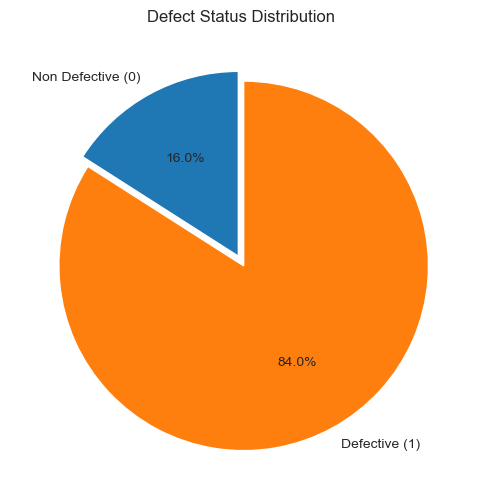

In [133]:
# Como es mencioando en la data esta desbalanceada
counts = df["DefectStatus"].value_counts().sort_index()

plt.figure(figsize=(8,6))

plt.pie(
    counts,
    labels=["Non Defective (0)", "Defective (1)"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03,0.03]
)

plt.title("Defect Status Distribution")

plt.show()

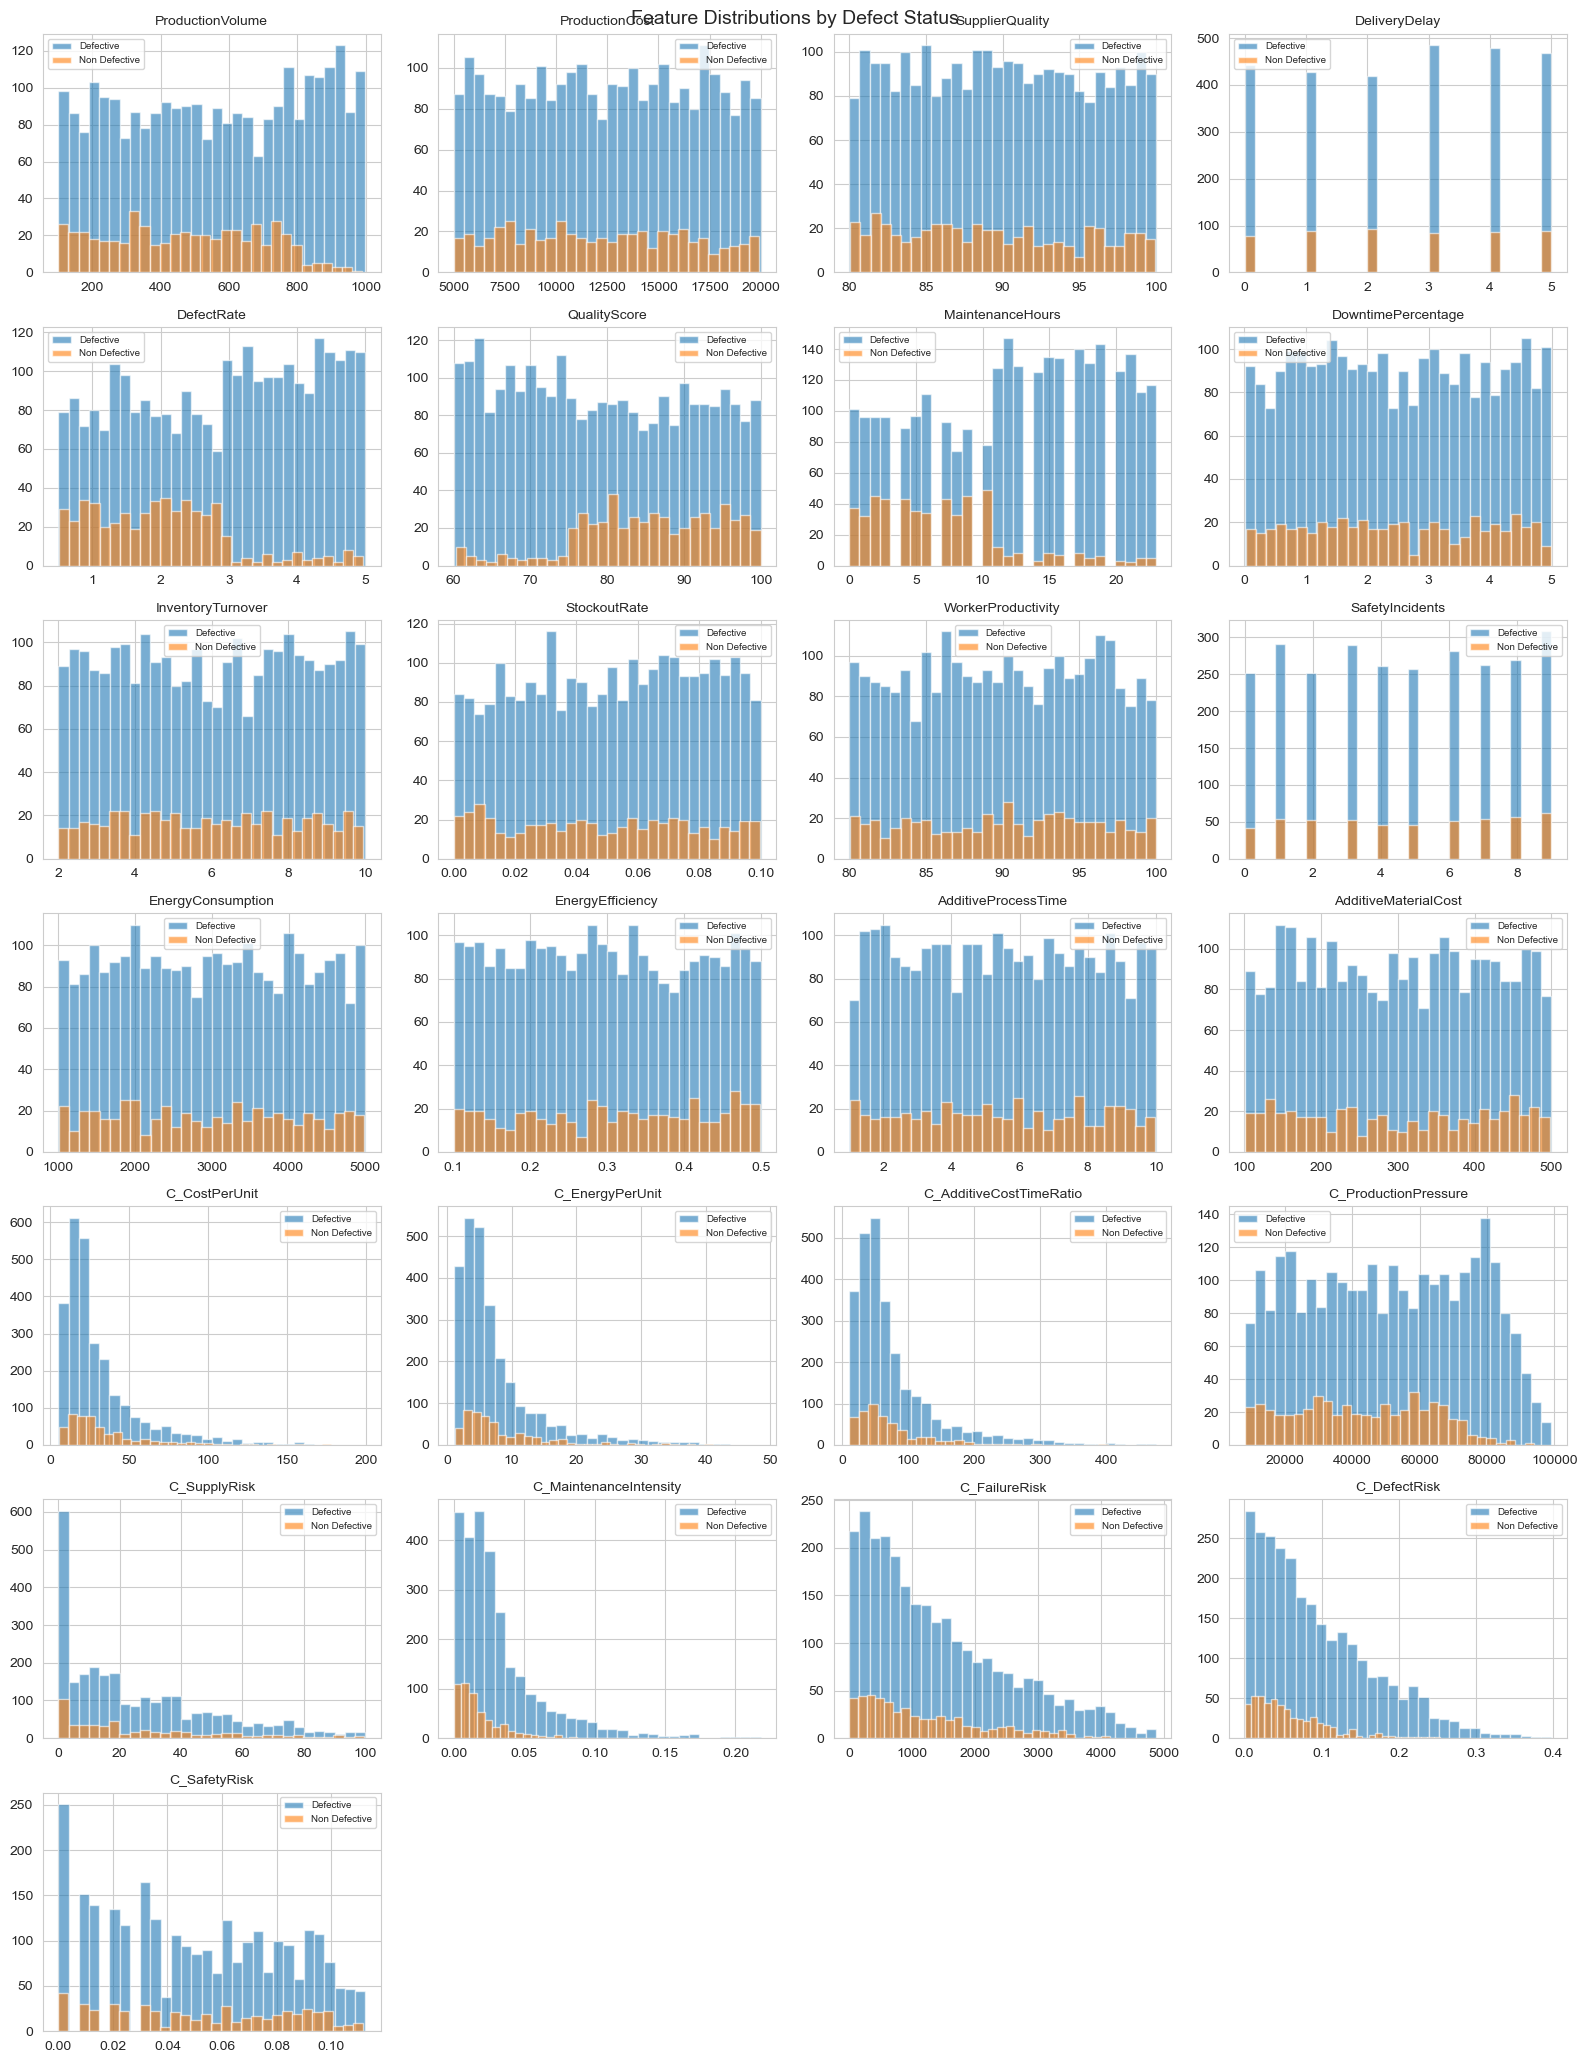

In [134]:
def plot_feature_distributions(df, target="DefectStatus", bins=30):

    features = df.drop(columns=[target]).columns
    n = len(features)

    cols = 4
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    axes = axes.flatten()

    for i, col in enumerate(features):

        axes[i].hist(df[df[target]==1][col], bins=bins, alpha=0.6, label="Defective")
        axes[i].hist(df[df[target]==0][col], bins=bins, alpha=0.6, label="Non Defective")

        axes[i].set_title(col, fontsize=10)
        axes[i].legend(fontsize=7)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Feature Distributions by Defect Status", fontsize=14)

    plt.tight_layout()
    plt.show()

plot_feature_distributions(df)

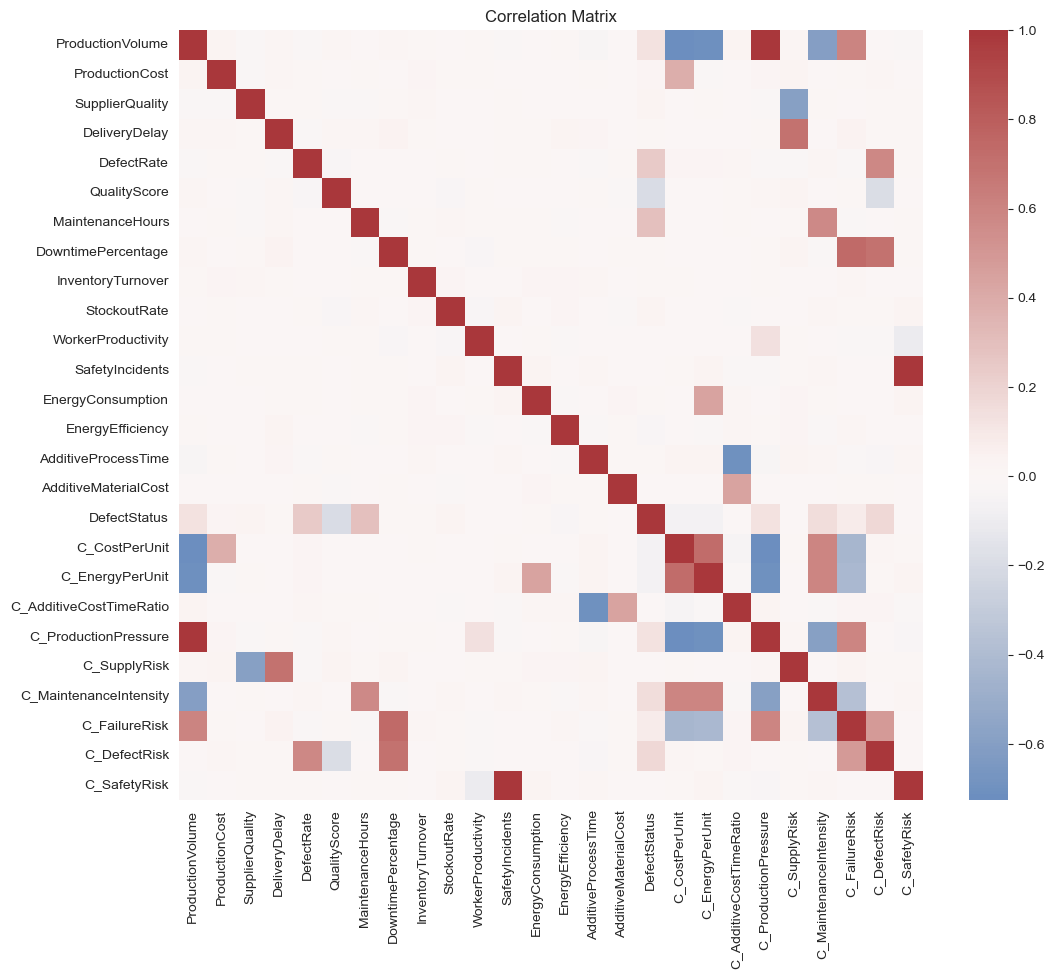

In [136]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="vlag",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [137]:
corr_target = corr["DefectStatus"].sort_values(ascending=False)

print(corr_target)

DefectStatus               1.000000
MaintenanceHours           0.297107
DefectRate                 0.245746
C_DefectRisk               0.176690
C_MaintenanceIntensity     0.150785
ProductionVolume           0.128973
C_ProductionPressure       0.127808
C_FailureRisk              0.076300
StockoutRate               0.040574
SupplierQuality            0.038184
ProductionCost             0.026720
InventoryTurnover          0.006733
AdditiveProcessTime        0.005619
DeliveryDelay              0.005425
EnergyConsumption          0.005039
DowntimePercentage         0.004128
C_AdditiveCostTimeRatio    0.001570
AdditiveMaterialCost      -0.000953
WorkerProductivity        -0.005224
C_SupplyRisk              -0.011571
C_SafetyRisk              -0.014958
SafetyIncidents           -0.016039
EnergyEfficiency          -0.035031
C_EnergyPerUnit           -0.060537
C_CostPerUnit             -0.067912
QualityScore              -0.199219
Name: DefectStatus, dtype: float64


In [138]:
# Seleccionar solo columnas que NO comienzan con "C_"
X = df  # .loc[:, ~df.columns.str.startswith("C_")]

# Eliminar también la variable objetivo
X = X.drop("DefectStatus", axis=1)

y = df["DefectStatus"]

In [139]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requiere dataframe
X_vif = X.copy()

# X_vif = X.select_dtypes(include=['int64','float64']).copy()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("Variance Inflation Factor (VIF)")
print(vif_data.sort_values("VIF", ascending=False))

Variance Inflation Factor (VIF)
                    feature         VIF
0          ProductionVolume  814.291780
19     C_ProductionPressure  808.985604
11          SafetyIncidents  646.056508
10       WorkerProductivity  645.994508
24             C_SafetyRisk  644.395539
2           SupplierQuality  584.590482
5              QualityScore   58.380058
7        DowntimePercentage   37.110785
22            C_FailureRisk   21.400074
1            ProductionCost   19.689301
4                DefectRate   18.672928
23             C_DefectRisk   18.166704
12        EnergyConsumption   17.456297
16            C_CostPerUnit   16.064338
17          C_EnergyPerUnit   15.155956
14      AdditiveProcessTime   14.418723
15     AdditiveMaterialCost   12.818601
3             DeliveryDelay   11.373304
20             C_SupplyRisk   10.744255
6          MaintenanceHours   10.203636
21   C_MaintenanceIntensity    9.757287
18  C_AdditiveCostTimeRatio    7.751840
8         InventoryTurnover    7.713502
13      

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Distribución original:")
print(y_train.value_counts())

Distribución original:
DefectStatus
1    2178
0     414
Name: count, dtype: int64


In [141]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [142]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Distribución después de SMOTE:")
print(pd.Series(y_train_bal).value_counts())

Distribución después de SMOTE:
DefectStatus
1    2178
0    2178
Name: count, dtype: int64


In [143]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_bal, y_train_bal)

pred_log = log_model.predict(X_test_scaled)

In [144]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

pred_rf = rf_model.predict(X_test_scaled)

In [145]:
from sklearn.metrics import classification_report

print("Logistic Regression Results")
print(classification_report(y_test, pred_log))

print("\nRandom Forest Results")
print(classification_report(y_test, pred_rf))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.38      0.70      0.49       103
           1       0.93      0.78      0.85       545

    accuracy                           0.77       648
   macro avg       0.65      0.74      0.67       648
weighted avg       0.84      0.77      0.79       648


Random Forest Results
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       103
           1       0.95      0.99      0.97       545

    accuracy                           0.95       648
   macro avg       0.93      0.86      0.89       648
weighted avg       0.94      0.95      0.94       648



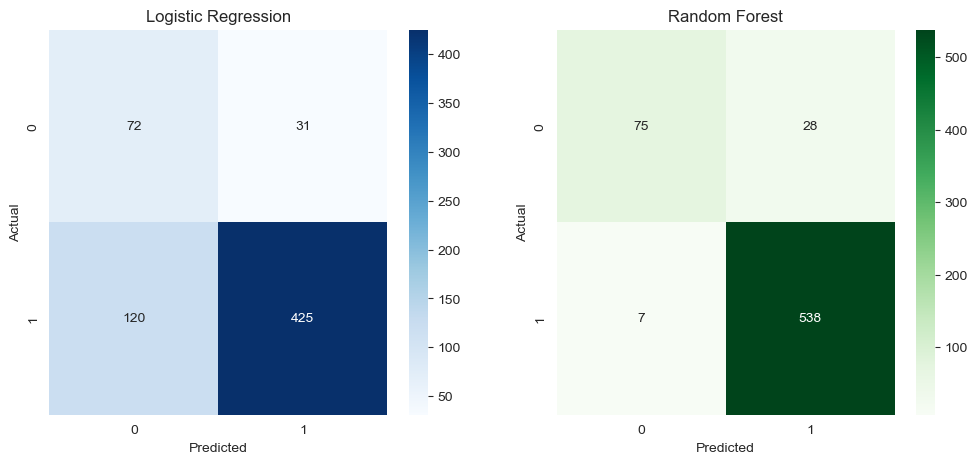

In [146]:

from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1,2, figsize=(12,5))

cm_log = confusion_matrix(y_test, pred_log)
cm_rf = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Logistic Regression")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=ax[1])
ax[1].set_title("Random Forest")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")


plt.show()

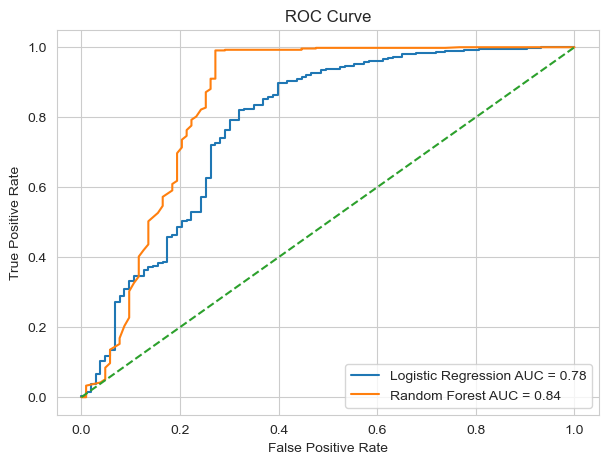

In [147]:
from sklearn.metrics import roc_curve, auc

prob_log = log_model.predict_proba(X_test_scaled)[:,1]
prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {auc_log:.2f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

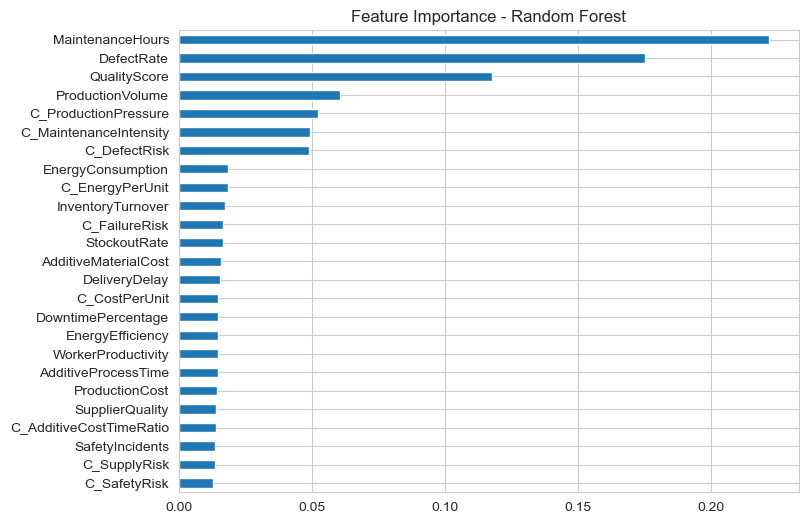

In [148]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance - Random Forest")

plt.show()

In [149]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross Validation F1 Scores:", scores)
print("Average F1:", scores.mean())

Cross Validation F1 Scores: [0.97752809 0.97522523 0.97857948 0.97412823 0.97857948]
Average F1: 0.9768081023759121


In [150]:
df_clear = df.copy()
X_scaled = scaler.transform(X)
df_clear["DefectProbability"] = rf_model.predict_proba(X_scaled)[:,1]


In [151]:
df_clear["RiskLevel"] = pd.cut(
    df_clear["DefectProbability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

In [173]:
# from datetime import datetime

# fecha = datetime.now().strftime("%Y%m%d")

# df_clear.to_csv(f"data_manu_limpia_{fecha}.csv", index=False)

# 